## Random Seed

In [1]:
import random
import torch
import numpy as np
import json
from secbert_utils import (
    set_seed, convert_span_to_number, load_counter,
    process_batch, process_data, MultiTaskIterableDataset, 
     ProcessedIterableDataset,
    MultiTaskModel, hits_at_k, FocalLoss, CB_CE_Loss, 
    fact_loss_fn, compute_loss, save_checkpoint, load_checkpoint,
    validate_model, evaluate_model, CLASSIFICATION_MISSING_VALUE, 
    NUMERIC_MISSING_VALUE
)

/home/mo1om/code/miniconda/envs/XBRL/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(torch.__version__)

2.9.0+cu130


## Dataset

In [3]:
from transformers import AutoTokenizer
import torch

# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# tokenizer = AutoTokenizer.from_pretrained("yiyanghkust/finbert-pretrain", local_files_only=True)
tokenizer = AutoTokenizer.from_pretrained("nlpaueb/sec-bert-base")

# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", local_files_only=True)

# 設定預設值
CLASSIFICATION_MISSING_VALUE = -100
NUMERIC_MISSING_VALUE = torch.finfo(torch.float32).max  # 3.4028235e+38

In [4]:
# IterableDataset

with open('../processed_data_task1_smaller/counter/tag_count_train_400k.json', 'r', encoding = 'utf-8') as file:
# with open('processed_iterable_dataset/counter/train_8k.json', 'r', encoding = 'utf-8') as file:
# with open('../processed_data_task1/counter/tag_count_train_data.json', 'r', encoding = 'utf-8') as file:    
    tag_counter = json.load(file)
    
# 想讓數量多的類別在前面

tag_counter = dict(sorted(tag_counter.items(), key = lambda item:item[1], reverse=True))
print(len(tag_counter))
count_threshold = 10
standard_rare_tags = {tag for tag, count in tag_counter.items() if count < count_threshold}
tag_list = [tag for tag in tag_counter.keys() if tag not in standard_rare_tags]
print(tag_list[:5])
print(f'Length of standard_rare_tags: {len(standard_rare_tags)}')
print(f'Length of all tags: {len(tag_list)}')

id2tag = {idx: tag for idx, tag in enumerate(tag_list)}
tag2id = {tag: idx for idx, tag in enumerate(tag_list)}

time_list = ['instant; past', 'instant; current', 'instant; future', 'period; past', 'period; current', 'period; future', 'period; past_current', 'period; current_future', 'period; past_future']
id2time = {idx: time for idx, time in enumerate(time_list)}
time2id = {time: idx for idx, time in enumerate(time_list)}

scale_list = [str(i) for i in range(-12, 13)]
id2scale = {idx: scale for idx, scale in enumerate(scale_list)}
scale2id = {scale: idx for idx, scale in enumerate(scale_list)}
# with open('processed_data_task1_smaller/counter/train_100k.json')

978
['custom', 'standard_rare', 'us-gaap:DebtInstrumentInterestRateStatedPercentage', 'us-gaap:DebtInstrumentBasisSpreadOnVariableRate1', 'us-gaap:DebtInstrumentFaceAmount']
Length of standard_rare_tags: 0
Length of all tags: 978


#### IterableDataset

#### Load Processed Iterable Dataset

In [5]:
from torch.utils.data import DataLoader
train_files = ["processed_iterable_dataset/train_400k.jsonl"]
valid_files = ["processed_iterable_dataset/valid_50k.jsonl"] 
test_files = ["processed_iterable_dataset/test_50k.jsonl"]

train_dataset = ProcessedIterableDataset(train_files)

valid_dataset = ProcessedIterableDataset(valid_files)

test_dataset = ProcessedIterableDataset(test_files)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)
valid_loader = DataLoader(valid_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)

In [6]:
import os

def count_lines(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        return sum(1 for _ in f)

# 計算訓練資料大約的 batch 數
train_total_samples = sum(count_lines(f) for f in train_files)
train_approx_batches = train_total_samples // batch_size

valid_total_samples = sum(count_lines(f) for f in valid_files)
valid_approx_batches = valid_total_samples // batch_size

test_total_samples = sum(count_lines(f) for f in test_files)
test_approx_batches = test_total_samples // batch_size


print(f"Train 預計數量: {train_total_samples}, 預計 {train_approx_batches} 個 batch")
print(f"Valid 預計數量: {valid_total_samples}, 預計 {valid_approx_batches} 個 batch")
print(f"Test 預計數量: {test_total_samples}, 預計 {test_approx_batches} 個 batch")

Train 預計數量: 728821, 預計 11387 個 batch
Valid 預計數量: 91168, 預計 1424 個 batch
Test 預計數量: 90337, 預計 1411 個 batch


## Count

In [7]:
# load counter result

def load_counter(target_attr):
    target_path = f'processed_iterable_dataset/counter/secbert_train_small_{target_attr}.json'

    with open(target_path, "r", encoding='utf-8') as f:
        data = json.load(f)
    return data

train_tag_counts = load_counter("tag")
train_tag_counts.pop('-100', None)
num_tag_samples = [train_tag_counts.get(str(tag2id[tag]), 0) for tag in tag_list]
print(f'Total tag class: {len(train_tag_counts)}')
train_time_counts = load_counter("time")
train_time_counts.pop('-100', None)
num_time_samples = [train_time_counts.get(str(time2id[time]), 0) for time in time_list]
print(train_time_counts)

train_neg_counts = load_counter("negative")
train_neg_counts.pop('-100', None)
num_neg_samples = [train_neg_counts.get(neg, 0) for neg in sorted(train_neg_counts.keys())]
print(train_neg_counts)

train_scale_counts = load_counter("scale")
train_scale_counts.pop('-100', None)
num_scale_samples = [train_scale_counts.get(str(scale2id[scale]), 0) for scale in scale_list]
print(train_scale_counts)

Total tag class: 978
{'6': 70691, '4': 124746, '3': 175155, '1': 195615, '0': 135307, '2': 14182, '5': 10629, '7': 351, '8': 490}
{'0': 701747, '1': 19527}
{'18': 328811, '10': 117673, '12': 152722, '15': 50895, '21': 18758, '8': 1695, '17': 38, '14': 13, '9': 20, '11': 18, '13': 17, '24': 30, '16': 37, '20': 2, '6': 5, '19': 3}


## Model

## Loss

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
# device = 'cpu'

cuda


In [9]:
# time loss
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np
from torch import nn
# 取得 time 類別的出現次數
time_class_counts = torch.tensor(num_time_samples)

total_samples = sum(train_time_counts.values())
num_classes = len(train_time_counts)

time_class_weights = {
    cls: total_samples / (num_classes * count) 
    for cls, count in train_time_counts.items()
}
time_class_weights = dict(sorted(time_class_weights.items(), key = lambda item:item[0]))
time_class_weights = list(time_class_weights.values())

time_smoothed_weights = np.log1p(time_class_weights)

MIN_WEIGHT =  1 # 設定最小值
time_smoothed_weights = np.clip(time_smoothed_weights, MIN_WEIGHT, None)
time_smoothed_weights[0] = 1.5
time_smoothed_weights[6] = 1.5
print(time_smoothed_weights)
time_class_weights = torch.tensor(time_smoothed_weights, dtype=torch.float).to(device)
time_loss_fn = nn.CrossEntropyLoss(weight = time_class_weights, ignore_index = CLASSIFICATION_MISSING_VALUE)

[1.5        1.         1.90167407 1.         1.         2.15193528
 1.5        5.44323412 5.11132642]


In [10]:
# scale loss
scale_class_weights = {
    15: 1.2,  21: 1.5
}
num_classes = len(scale_list)
weights_list = [scale_class_weights.get(i, 1.0) for i in range(num_classes)]

scale_class_weights = torch.tensor(weights_list, dtype=torch.float).to(device)

# 定義 loss function
scale_loss_fn = nn.CrossEntropyLoss(weight=scale_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE)

In [11]:
# train_time_counts = get_value_counts(train_loader, "time")
# num_time_samples = [train_time_counts.get(time, 0) for time in sorted(train_time_counts.keys())]
tag_loss_fn = CB_CE_Loss(num_tag_samples, beta = 0.99)
time_loss_fn = CB_CE_Loss(num_time_samples)
neg_loss_fn = FocalLoss(alpha=0.25, gamma=3.0, reduction="mean")


## Train

### Train

#### Init & Setting

In [12]:
def get_task_weights(epoch):

    if epoch < 3:
       return {"tag": 15.0, "time": 1.0, "scale": 0.1, "negative": 3}  
    elif epoch < 8:
        return {"tag": 10.0, "time": 1.2, "scale": 0.2, "negative": 5}          
    elif epoch < 12:
        return {"tag": 10.0, "time": 1.5, "scale": 0.2, "negative": 5}  
    else:
        return {"tag": 8.0, "time": 1.0, "scale": 0.2, "negative": 3}


In [13]:
import wandb
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F
from transformers import get_scheduler
from tqdm import tqdm
import os

num_warmup_steps = 5
num_epochs = 30
eval_step = 20000 # 150222 個 batch
# checkpoint_save_step = 50
task_weights = {"tag": 10.0, "time": 0.3, "scale": 0.2, "negative": 10.0}  
# task_weights = get_task_weights(0)
patience = 5
max_saved_models = 2
saved_models = [] 

model_name = "secbert"
date = "0426"
index = 173
run_name = f"{model_name}-{date}-{index}"

model = MultiTaskModel(
    "nlpaueb/sec-bert-base",
    num_tags = len(tag_list), 
    num_times = len(time_list),
    num_scales= len(scale_list)
)


bert_lr = 1e-5
tag_head_lr = 5e-4
time_head_lr = 1e-5
scale_head_lr = 3e-5
negative_head_lr = 2e-5

optimizer = AdamW([
    {"params": model.bert.parameters(), "lr": bert_lr, "weight_decay": 1e-2},  
    {"params": model.tag_head.parameters(), "lr": tag_head_lr,  "weight_decay": 1e-2},  
    {"params": model.time_head.parameters(), "lr": time_head_lr,  "weight_decay": 1e-2},  
    {"params": model.scale_head.parameters(), "lr": scale_head_lr,  "weight_decay": 1e-2},
    {"params": model.negative_head.parameters(), "lr": negative_head_lr,  "weight_decay": 1e-2},  
])

num_total_steps= num_epochs * train_approx_batches
scheduler = CosineAnnealingLR(optimizer, T_max = num_total_steps // 4, eta_min = 1e-7)

device = "cuda" if torch.cuda.is_available() else "cpu"
# device = 'cpu'
print(device)
best_val_loss = float("inf")
early_stop_counter = 0 


os.makedirs(f'model_weight/{model_name}', exist_ok=True)
os.makedirs(f'check_point/{model_name}', exist_ok=True)


# wandb.init(
#     project = "multi-task-model",
#     resume="allow",
#     id='wqugd5cx',
#     name = f'{run_name}_cont_0330_173',
#     config = {
#         "learning_rates": { 
#             "bert": bert_lr,
#             "tag_head": tag_head_lr,
#             "time_head": time_head_lr,
#             "scale_head": scale_head_lr,
#             "negative_head": negative_head_lr
#         },
#         "epochs": num_epochs,
#         "task_weights": task_weights,
#         "train_data_size": train_total_samples,
#         "valid_data_size": valid_total_samples,
#         "eval_step": eval_step,
#         "model": model
#     },
# )

# wandb.watch(model, log="all")

cuda


### 恢復訓練

In [14]:
# last_step = 820000
# o_date = '0426'

# model = MultiTaskModel(
#     "nlpaueb/sec-bert-base",
#     num_tags = len(tag_list), 
#     num_times = len(time_list),
#     num_scales= len(scale_list)
# )
# model.to(device)
# bert_lr = 1e-5
# tag_head_lr = 5e-4
# time_head_lr = 1e-5
# scale_head_lr = 3e-5
# negative_head_lr = 2e-5

# optimizer = AdamW([
#     {"params": model.bert.parameters(), "lr": bert_lr, "weight_decay": 1e-2},  
#     {"params": model.tag_head.parameters(), "lr": tag_head_lr,  "weight_decay": 1e-2},  
#     {"params": model.time_head.parameters(), "lr": time_head_lr,  "weight_decay": 1e-2},  
#     {"params": model.scale_head.parameters(), "lr": scale_head_lr,  "weight_decay": 1e-2},
#     {"params": model.negative_head.parameters(), "lr": negative_head_lr,  "weight_decay": 1e-2},  
# ])


# num_total_steps= num_epochs * train_approx_batches
# scheduler = CosineAnnealingLR(optimizer, T_max = num_total_steps // 4, eta_min = 1e-7)

# checkpoint_path = f"check_point/{model_name}/{o_date}_{index}_step{last_step}.pth"
# print(checkpoint_path)
# if os.path.exists(checkpoint_path):
#     start_epoch, start_step = load_checkpoint(model, optimizer, scheduler, checkpoint_path, device)
# else:
#     print('Check point step not exist.')

# # **繼續訓練**
# progress_bar = tqdm(range(start_step, num_total_steps), desc="Training", dynamic_ncols=True)
# step = start_step

# for epoch in range(start_epoch, num_epochs):
#     if early_stop_counter >= patience:
#         print("Early stopping triggered before starting a new epoch. Training stopped.")
#         break  # 停止整個 training loop
#     model.train()
#     print(f"Task weight: {task_weights}")
#     train_loss = 0
#     train_samples = 0
#     train_batch_count = 0
#     train_losses = {}
    
#     for batch in train_loader:
#         if early_stop_counter >= patience:
#             print("Early stopping triggered during training. Stopping current epoch.")
#             break 
            
#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         start_tokens = batch["start_token"].to(device)
#         end_tokens = batch["end_token"].to(device)
#         values = batch["value"].to(device)
        
#         targets = {
#             "tag": batch["tag"].to(device),
#             "time": batch["time"].to(device),
#             "scale": batch["scale"].to(device),
#             "negative": batch["negative"].to(device)
#         }

#         outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
#         loss, losses = compute_loss(outputs, targets, values, task_weights)
       
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         scheduler.step()

       
        
#         # 累計 loss
#         train_loss += loss.item()
#         for key, val in losses.items():
#             train_losses[key] = train_losses.get(key, 0) + val
            
#         train_samples += len(batch["input_ids"])
#         train_batch_count += 1
        
#         step += 1
#         epoch_progress = step / train_approx_batches
        
#         # progress_bar.set_postfix(loss = loss.item())
#         progress_bar.set_postfix(
#             loss = loss.item(),
#             epoch = f"{epoch_progress:.2f}"
#         )
#         progress_bar.update(1)

#         wandb.log({
#             "step": step, 
#             "epoch": epoch_progress,
#             "lr_bert": optimizer.param_groups[0]['lr'],
#             "lr_tag_head": optimizer.param_groups[1]['lr'],
#             "lr_time_head": optimizer.param_groups[2]['lr'],
#             "lr_scale_head": optimizer.param_groups[3]['lr'],
#             "lr_negative_head": optimizer.param_groups[4]['lr'],
#         })        
    
#         if step % eval_step == 0:
#             save_checkpoint(model, optimizer, scheduler, epoch, step, f'check_point/{model_name}/{date}_{index}_step{step}.pth')
            
#             avg_train_loss = train_loss / train_batch_count if train_batch_count > 0 else 0
#             train_loss_dict = {f"train_loss_{key}": train_losses[key] / train_batch_count for key in train_losses} if train_batch_count > 0 else {}
            
#             train_loss = 0
#             train_batch_count = 0
#             train_losses = {}

#             val_loss, val_losses = validate_model(model, valid_loader, task_weights, device)
#             val_loss_dict = {f"val_loss_{key}": val_losses[key] for key in val_losses}
#             model.train()
            
#             wandb.log({
#                 "step": step, 
#                 "epoch_progress": epoch_progress,
#                 "train_loss": avg_train_loss,
#                 "val_loss": val_loss,
#                 **train_loss_dict,
#                 **val_loss_dict
#             })
    
#             print(f"\nStep {step} Epoch {epoch_progress:.2f}: \nTrain Loss = {avg_train_loss:.4f} Validation Loss = {val_loss:.4f}")
#             print(f"Validation Loss Breakdown: {val_losses}")
        
#             # Save model if validation loss improves
#             if val_loss < best_val_loss:
#                 print(f"Validation loss improved from {best_val_loss:.4f} to {val_loss:.4f}. Saving model...")
#                 best_val_loss = val_loss
#                 early_stop_counter = 0
                
#                 model_save_path_epoch = f"model_weight/{model_name}/{date}_{index}_step{step+1}.pt"
#                 torch.save(model.state_dict(), model_save_path_epoch)
#                 saved_models.append(model_save_path_epoch)
#                 if len(saved_models) > max_saved_models:
#                     oldest_model = saved_models.pop(0) 
#                     if os.path.exists(oldest_model):
#                         os.remove(oldest_model)
#                         print(f"Removed old model: {oldest_model}")
                        
#             else:
#                 early_stop_counter += 1
#                 print(f"No improvement. Early stop counter: {early_stop_counter}/{patience}")
        
#             # Early stopping check
#             if early_stop_counter >= patience:
#                 print("Early stopping triggered. Training stopped.")
#                 break

# # 結束 wandb
# wandb.finish()

In [15]:
print()

## Test

In [16]:
# model.to(device)
from collections import defaultdict
import csv
import os
import torch
import pandas as pd

def evaluate_model(model, model_save_path, error_file_path, test_loader, task_weights, device, save_errors=False):
    os.environ["WANDB_DISABLED"] = "true"
    model.load_state_dict(torch.load(model_save_path))
    model.eval()
    
    all_losses = {'tag': 0, 'time': 0, 'fact': 0, 'scale': 0, 'negative': 0}
    total_hits = {"hits_1": 0, "hits_3": 0, "hits_5": 0}
    predictions = defaultdict(list)
    ground_truths = defaultdict(list)
    errors = defaultdict(list)  # 存放錯誤樣本
    test_samples = 0
    test_batch_count = 0

    
    fact_res = []
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            start_tokens = batch["start_token"].to(device)
            end_tokens = batch["end_token"].to(device)
            values = batch["value"].to(device)
            
            targets = {
                "tag": batch["tag"].to(device),
                "time": batch["time"].to(device),
                "fact": batch["fact"].to(device),
                "scale": batch["scale"].to(device),
                "negative": batch["negative"].to(device)
            }
            
            outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
            loss, losses, tag_hits_k = compute_loss(outputs, targets, values, task_weights, hits_k = True,tag_loss_fn=tag_loss_fn,
                                       time_loss_fn=time_loss_fn,
                                       scale_loss_fn=scale_loss_fn,
                                       neg_loss_fn=neg_loss_fn)
            test_samples += len(batch["input_ids"])
            test_batch_count += 1
            
            # print(outputs)
            if tag_hits_k:
                for key in total_hits:
                    total_hits[key] += tag_hits_k[key]
                    
            for key in all_losses:
                if key in losses:
                    all_losses[key] += losses[key].item()
                
            for key in ["scale", "negative", "tag", "time"]:
                pred = torch.argmax(outputs[key], dim=-1).cpu().tolist()
                true = targets[key].cpu().tolist()

                # **移除 -100 (ignore_index)**
                for i, (p, t) in enumerate(zip(pred, true)):
                    # if t != CLASSIFICATION_MISSING_VALUE:
                    predictions[key].append(p)
                    ground_truths[key].append(t)
                    if p != t:  # **記錄錯誤預測**
                        errors[key].append({
                            "batch_idx": batch_idx,
                            "sample_idx": i,
                            "true": t,
                            "pred": p,
                        })

            # **處理數值預測 (fact)**
            classification_loss = nn.CrossEntropyLoss(ignore_index=CLASSIFICATION_MISSING_VALUE)
            if "fact" in targets:
                 # 負號預測
                negative_pred = outputs["negative"].argmax(dim=-1).cpu().numpy()  # [batch_size]
                losses["negative"] = classification_loss(outputs["negative"], targets["negative"])
                
                #  Scale 預測
                if "scale" in outputs:
                    scale_pred_class = outputs["scale"].argmax(dim=-1).cpu().numpy()  # [batch_size]
                else:
                    scale_pred_class = np.ones_like(values.cpu().numpy(), dtype=np.int64)  # [batch_size]
            
                # scale → 數值
                id2scale_np = np.array([float(id2scale[idx]) for idx in range(len(id2scale))], dtype=np.float64)  
                scale_pred_values = id2scale_np[scale_pred_class] # [batch_size]

                values = values.cpu().numpy()

                # 計算 fact_pred
                fact_pred = values * (-1) ** negative_pred * (10 ** scale_pred_values)
                fact_target = targets["fact"].view(-1).cpu().numpy()

                for i, (p, t, neg, scale, scale_val, val) in enumerate(zip(fact_pred, fact_target, negative_pred, scale_pred_class, scale_pred_values, values)):
                    if t == NUMERIC_MISSING_VALUE:
                        continue
                
                    predictions["fact"].append(p)
                    ground_truths["fact"].append(t)
                    
                   
                    fact_res.append({
                        "batch_idx": batch_idx,
                        "sample_idx": i,
                        "true": t,
                        "pred": p,
                        "negative_pred": neg,
                        "scale_pred": scale,
                        "scale_val": scale_val,
                        "value": val
                    })
                    if abs(p - t) > 1e-2:  # 判斷是否錯誤
                        errors["fact"].append({
                            "batch_idx": batch_idx,
                            "sample_idx": i,
                            "true": t,
                            "pred": p,
                        })

    for key in all_losses:
        all_losses[key] /= test_batch_count
    
    # **平均 batch 結果**
    avg_hits_k = {key: total_hits[key] / test_batch_count for key in total_hits}
        

    # **存錯誤樣本到 CSV**
    if save_errors:
        for key, error_list in errors.items():
            error_file = f"{error_file_path}_errors_{key}.csv"
            with open(error_file, mode="w", newline="") as f:
                writer = csv.DictWriter(f, fieldnames=["batch_idx", "sample_idx", "true", "pred"])
                writer.writeheader()
                writer.writerows(error_list)
            print(f"🚨 錯誤樣本已儲存到 {error_file}")

    if fact_res:
        fact_res_df = pd.DataFrame(fact_res)
        fact_res_df.to_csv('fact_res.csv', index = False)
    return all_losses, dict(predictions), dict(ground_truths), avg_hits_k


In [17]:
 
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F
from transformers import get_scheduler
from tqdm import tqdm
import os

num_warmup_steps = 5
num_epochs = 30
eval_step = 20000 # 150222 個 batch
# checkpoint_save_step = 50
task_weights = {"tag": 10.0, "time": 0.3, "scale": 0.2, "negative": 10.0}  
# task_weights = get_task_weights(0)
patience = 5
max_saved_models = 2
saved_models = [] 


model_name = "secbert"
date = "0426"
index = 173

last_step = 60000
o_date = '0426'
model = MultiTaskModel(
    "nlpaueb/sec-bert-base",
    num_tags = len(tag_list), 
    num_times = len(time_list),
    num_scales= len(scale_list)
)
model.to(device)
bert_lr = 1e-5
tag_head_lr = 5e-4
time_head_lr = 1e-5
scale_head_lr = 3e-5
negative_head_lr = 2e-5

optimizer = AdamW([
    {"params": model.bert.parameters(), "lr": bert_lr, "weight_decay": 1e-2},  
    {"params": model.tag_head.parameters(), "lr": tag_head_lr,  "weight_decay": 1e-2},  
    {"params": model.time_head.parameters(), "lr": time_head_lr,  "weight_decay": 1e-2},  
    {"params": model.scale_head.parameters(), "lr": scale_head_lr,  "weight_decay": 1e-2},
    {"params": model.negative_head.parameters(), "lr": negative_head_lr,  "weight_decay": 1e-2},  
])


num_total_steps= num_epochs * train_approx_batches
scheduler = CosineAnnealingLR(optimizer, T_max = num_total_steps // 4, eta_min = 1e-7)

checkpoint_path = f"check_point/{model_name}/{o_date}_{index}_step{last_step}.pth"
model_save_path = f"model_weight/{model_name}/{date}_{index}_step20001.pt"
error_file_path = f'error_analysis/{model_name}_{date}_{index}'
print(model_save_path)
test_all_losses, test_predictions, test_ground_truths, avg_hits_k = evaluate_model(model, model_save_path, error_file_path, test_loader, task_weights, device, True)
print(test_all_losses)
print(avg_hits_k)

model_weight/secbert/0426_173_step20001.pt
🚨 錯誤樣本已儲存到 error_analysis/secbert_0426_173_errors_scale.csv
🚨 錯誤樣本已儲存到 error_analysis/secbert_0426_173_errors_negative.csv
🚨 錯誤樣本已儲存到 error_analysis/secbert_0426_173_errors_tag.csv
🚨 錯誤樣本已儲存到 error_analysis/secbert_0426_173_errors_time.csv
🚨 錯誤樣本已儲存到 error_analysis/secbert_0426_173_errors_fact.csv
{'tag': 0.013517842662689558, 'time': 0.0110903936451454, 'fact': 0.0, 'scale': 0.07396237262743643, 'negative': 0.0023973843589665295}
{'hits_1': 0.6292767762377984, 'hits_3': 0.8642105330151134, 'hits_5': 0.9290892500799709}


In [18]:
attrs = ['scale', 'negative', 'tag', 'time', 'fact']
for attr in (attrs):
    df = pd.DataFrame({
        f"true_{attr}": test_ground_truths[attr],
        f"pred_{attr}": test_predictions[attr],
    })
    
    # 存成 CSV
    df.to_csv(f"result/{model_name}_{date}_{index}_result_{attr}.csv", index=False, encoding="utf-8")

### Recall、Accuracy...

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

def evaluate_classification(y_true, y_pred, attr = None):
    """
    Evaluate classification model performance.
    
    Args:
        y_true (array-like): Ground truth (true class labels).
        y_pred (array-like): Predicted class labels.
        attr (str): The attribute need to be predict.
    Returns:
        dict: A dictionary containing all evaluation metrics.
    """
    metrics = {}
    # **移除 MISSING VALUE**
    valid_indices = [i for i, t in enumerate(y_true) if t != CLASSIFICATION_MISSING_VALUE]
    y_true = [y_true[i] for i in valid_indices]
    y_pred = [y_pred[i] for i in valid_indices]

    # **計算各類別的數量**
    unique_classes, class_counts = np.unique(y_true, return_counts=True)
    class_weights = {cls: count / len(y_true) for cls, count in zip(unique_classes, class_counts)}

    # **基本指標**
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['precision'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['recall'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['f1_score'] = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # **加權指標**
    weighted_precision, weighted_recall, weighted_f1_score, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    metrics['weighted_precision'] = weighted_precision
    metrics['weighted_recall'] = weighted_recall
    metrics['weighted_f1_score'] = weighted_f1_score

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    metrics['confusion_matrix'] = cm
    
    # Classification report (for detailed metrics)
    metrics['classification_report'] = classification_report(y_true, y_pred, zero_division=0)
    
    # Print results
    print(f"\n{attr.upper()} Evaluation Metrics:")
    print(f"Weighted F1 Score: {metrics['weighted_f1_score']:.4f}")
    print(f"Weighted Recall: {metrics['weighted_recall']:.4f}")
    print(f"Weighted Precision: {metrics['weighted_precision']:.4f}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")

    print(f"F1 Score (macro): {metrics['f1_score']:.4f}")
    print(f"Precision (macro): {metrics['precision']:.4f}")
    print(f"Recall (macro): {metrics['recall']:.4f}")
        
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(metrics['classification_report'])
    
    return metrics


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_regression(y_true, y_pred, attr = None, plot_residuals = True):
    """
    Evaluate regression model performance.
    
    Args:
        y_true (array-like): Ground truth (true values).
        y_pred (array-like): Predicted values.
        attr (str, optional): The attribute name for display.
        plot_residuals (bool, optional): Whether to plot the residuals. Defaults to True.
    
    Returns:
        dict: A dictionary containing all evaluation metrics.
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)
    metrics = {}
    
    # 計算回歸指標
    metrics['mse'] = mean_squared_error(y_true, y_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])  # 均方根誤差 (RMSE)
    metrics['mae'] = mean_absolute_error(y_true, y_pred)  # 平均絕對誤差 (MAE)
    metrics['r2'] = r2_score(y_true, y_pred)  # R² 決定係數
    
    # 印出評估結果
    print(f"\n{attr.upper()} Regression Metrics:")
    print(f"MSE: {metrics['mse']:.4f}")
    print(f"RMSE: {metrics['rmse']:.4f}")
    print(f"MAE: {metrics['mae']:.4f}")
    print(f"R² Score: {metrics['r2']:.4f}")
    
    # 繪製殘差圖（Residual Plot）
    if plot_residuals:
        residuals = y_true - y_pred
        plt.figure(figsize=(8, 6))
        plt.scatter(y_pred, residuals, alpha=0.6, color='blue', edgecolors='black')
        plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
        plt.xlabel("Predicted Values")
        plt.ylabel("Residuals")
        plt.title("Residual Plot")
        plt.grid()
        plt.show()
    
    return metrics


In [21]:
import pandas as pd
time_result = pd.read_csv('result/secbert_0426_173_result_time.csv')
tag_result = pd.read_csv('result/secbert_0426_173_result_tag.csv')
scale_result = pd.read_csv('result/secbert_0426_173_result_scale.csv')
negative_result = pd.read_csv('result/secbert_0426_173_result_negative.csv')

In [22]:
CLASSIFICATION_MISSING_VALUE = -100

In [23]:
time_metrics = evaluate_classification(time_result['true_time'].tolist(), time_result['pred_time'].tolist(), 'time')
scale_metrics = evaluate_classification(scale_result['true_scale'].tolist(), scale_result['pred_scale'].tolist(), 'scale')
negative_metrics = evaluate_classification(negative_result['true_negative'], negative_result['pred_negative'], 'negative')
tag_metrics = evaluate_classification(tag_result['true_tag'], tag_result['pred_tag'], 'tag')



TIME Evaluation Metrics:
Weighted F1 Score: 0.5445
Weighted Recall: 0.5748
Weighted Precision: 0.5653
Accuracy: 0.5748
F1 Score (macro): 0.3594
Precision (macro): 0.4609
Recall (macro): 0.3517

Confusion Matrix:
[[ 9263  5219     9  1808   439     1     3     0     0]
 [ 3960 18086    76  1125   846    10     9     0     0]
 [  428   388  1352   146    51    21     0     0     0]
 [ 1253  1478     0 15229  3502    15    37     0     0]
 [  508  2053     0  4822  7506    26   263     0     0]
 [   99   190     0   667   242    81     3     0     0]
 [  208  1521     0  3688  3075     2   258     0     0]
 [    2     5     0    12    18     1     1     0     0]
 [    0    16     0    19    29     1     0     0     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.55      0.57     16742
           1       0.62      0.75      0.68     24112
           2       0.94      0.57      0.71      2386
           3       0.55      0.7


TIME Evaluation Metrics:
Weighted F1 Score: 0.5445
Weighted Recall: 0.5748
Weighted Precision: 0.5653
Accuracy: 0.5748
F1 Score (macro): 0.3594
Precision (macro): 0.4609
Recall (macro): 0.3517

Confusion Matrix:
[[ 9263  5219     9  1808   439     1     3     0     0]
 [ 3960 18086    76  1125   846    10     9     0     0]
 [  428   388  1352   146    51    21     0     0     0]
 [ 1253  1478     0 15229  3502    15    37     0     0]
 [  508  2053     0  4822  7506    26   263     0     0]
 [   99   190     0   667   242    81     3     0     0]
 [  208  1521     0  3688  3075     2   258     0     0]
 [    2     5     0    12    18     1     1     0     0]
 [    0    16     0    19    29     1     0     0     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.55      0.57     16742
           1       0.62      0.75      0.68     24112
           2       0.94      0.57      0.71      2386
           3       0.55      0.7

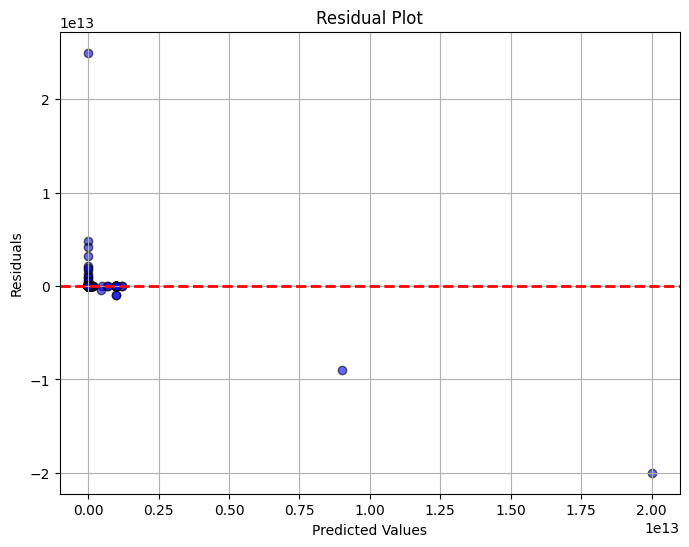


TAG Evaluation Metrics:
Weighted F1 Score: 0.5999
Weighted Recall: 0.6293
Weighted Precision: 0.6081
Accuracy: 0.6293
F1 Score (macro): 0.3848
Precision (macro): 0.4333
Recall (macro): 0.4156

Confusion Matrix:
[[18607  1190    90 ...     0     1     0]
 [ 3166  3331    39 ...     0     1     0]
 [   39     0  1504 ...     0     0     0]
 ...
 [    4     0     0 ...     0     0     0]
 [   11     1     0 ...     0     2     0]
 [    5     0     0 ...     0     0     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.76      0.69     24644
           1       0.55      0.36      0.44      9175
           2       0.81      0.91      0.86      1646
           3       0.79      0.96      0.87      1289
           4       0.62      0.71      0.66      1341
           5       0.69      0.84      0.76      1228
           6       0.71      0.94      0.81      1030
           7       0.85      0.86      0.86       802
           8 

In [24]:
time_metrics = evaluate_classification(test_ground_truths['time'], test_predictions['time'], 'time')
scale_metrics = evaluate_classification(test_ground_truths['scale'], test_predictions['scale'], 'scale')
negative_metrics = evaluate_classification(test_ground_truths['negative'], test_predictions['negative'], 'negative')
fact_metrics = evaluate_regression(test_ground_truths['fact'], test_predictions['fact'], 'fact')
tag_metrics = evaluate_classification(test_ground_truths['tag'], test_predictions['tag'], 'tag')


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_regression(y_true, y_pred, attr="Value", tolerance=1e-2, plot_residuals=True):
    """
    Evaluate regression model performance with a focus on Correct Rate first.
    
    Args:
        y_true (array-like): Ground truth.
        y_pred (array-like): Predicted values.
        attr (str): Attribute name for display.
        tolerance (float): The allowed margin of error to consider a prediction "Correct". 
                           (e.g. 1e-2 means diff <= 0.01 is correct).
        plot_residuals (bool): Whether to plot residuals.
        
    Returns:
        dict: Dictionary containing all metrics.
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)
    
    # 1. Calculate Correct Rate (Accuracy)
    # We define correctness as absolute difference <= tolerance
    diff = np.abs(y_true - y_pred)
    correct_mask = diff <= tolerance
    incorrect_mask = ~correct_mask
    
    accuracy = np.mean(correct_mask)
    
    metrics = {'accuracy': accuracy}

    print(f"\n{'='*10} {attr.upper()} EVALUATION {'='*10}")
    print(f"Tolerance Threshold: <= {tolerance}")
    print(f"Correct Rate (Accuracy): {accuracy:.2%} ({np.sum(correct_mask)}/{len(y_true)})")
    
    # 2. Calculate Standard Regression Metrics (Global)
    metrics['mse'] = mean_squared_error(y_true, y_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])
    metrics['mae'] = mean_absolute_error(y_true, y_pred)
    metrics['r2'] = r2_score(y_true, y_pred)
    
    print(f"\n--- Global Metrics (All Samples) ---")
    print(f"RMSE: {metrics['rmse']:.4f}")
    print(f"MAE : {metrics['mae']:.4f}")
    print(f"R²  : {metrics['r2']:.4f}")
    
    # 3. Conditional Metrics (Optional: Analyze the 'Incorrect' ones specifically)
    if np.sum(incorrect_mask) > 0:
        rmse_incorrect = np.sqrt(mean_squared_error(y_true[incorrect_mask], y_pred[incorrect_mask]))
        mae_incorrect = mean_absolute_error(y_true[incorrect_mask], y_pred[incorrect_mask])
        print(f"\n--- Error Analysis (Incorrect Samples Only) ---")
        print(f"RMSE (Incorrect): {rmse_incorrect:.4f}")
        print(f"MAE  (Incorrect): {mae_incorrect:.4f}")
        metrics['rmse_incorrect'] = rmse_incorrect
    
    # 4. Residual Plot (Enhanced with Color Coding)
    if plot_residuals:
        residuals = y_true - y_pred
        plt.figure(figsize=(10, 6))
        
        # Plot Correct samples in Green, Incorrect in Red
        plt.scatter(y_pred[correct_mask], residuals[correct_mask], 
                    alpha=0.6, color='green', label=f'Correct (Diff ≤ {tolerance})', s=30)
        plt.scatter(y_pred[incorrect_mask], residuals[incorrect_mask], 
                    alpha=0.6, color='red', label='Incorrect', s=30)

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_regression(y_true, y_pred, attr="Value", tolerance=1e-2, plot_residuals=True):
    """
    Evaluate regression model performance including Correct Rate and SMAPE.
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)
    
    # --- 1. Calculate Correct Rate (Accuracy) ---
    diff = np.abs(y_true - y_pred)
    correct_mask = diff <= tolerance
    incorrect_mask = ~correct_mask
    
    accuracy = np.mean(correct_mask)
    metrics = {'accuracy': accuracy}

    print(f"\n{'='*10} {attr.upper()} EVALUATION {'='*10}")
    print(f"Tolerance Threshold: <= {tolerance}")
    print(f"Correct Rate (Accuracy): {accuracy:.2%} ({np.sum(correct_mask)}/{len(y_true)})")
    
    # --- 2. Calculate Standard Regression Metrics ---
    metrics['mse'] = mean_squared_error(y_true, y_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])
    metrics['mae'] = mean_absolute_error(y_true, y_pred)
    metrics['r2'] = r2_score(y_true, y_pred)

    # --- 3. Calculate SMAPE ---
    # Formula: 2 * |y_true - y_pred| / (|y_true| + |y_pred|)
    # We add a small epsilon to denominator to avoid division by zero
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    
    # Handle the case where both true and pred are 0 (0/0 -> NaN, technically 0 error)
    # We replace 0s in denominator with a tiny number or handle mask
    with np.errstate(divide='ignore', invalid='ignore'):
        smape_values = numerator / denominator
        smape_values[denominator == 0] = 0.0 # If both are 0, error is 0
    
    metrics['smape'] = np.mean(smape_values) * 100 # Convert to percentage

    print(f"\n--- Global Metrics (All Samples) ---")
    print(f"RMSE : {metrics['rmse']:.4f}")
    print(f"MAE  : {metrics['mae']:.4f}")
    print(f"SMAPE: {metrics['smape']:.2f}%") # Added SMAPE output
    print(f"R²   : {metrics['r2']:.4f}")
    
    # --- 4. Conditional Metrics (Incorrect Samples Only) ---
    if np.sum(incorrect_mask) > 0:
        rmse_incorrect = np.sqrt(mean_squared_error(y_true[incorrect_mask], y_pred[incorrect_mask]))
        mae_incorrect = mean_absolute_error(y_true[incorrect_mask], y_pred[incorrect_mask])
        
        # Calculate SMAPE for incorrect samples only
        smape_incorrect = np.mean(smape_values[incorrect_mask]) * 100
        
        print(f"\n--- Error Analysis (Incorrect Samples Only) ---")
        print(f"RMSE (Incorrect) : {rmse_incorrect:.4f}")
        print(f"MAE  (Incorrect) : {mae_incorrect:.4f}")
        print(f"SMAPE (Incorrect): {smape_incorrect:.2f}%")
        metrics['rmse_incorrect'] = rmse_incorrect

    # --- 5. Residual Plot ---
    if plot_residuals:
        residuals = y_true - y_pred
        plt.figure(figsize=(10, 6))
        
        plt.scatter(y_pred[correct_mask], residuals[correct_mask], 
                    alpha=0.6, color='green', label=f'Correct (Diff ≤ {tolerance})', s=30)
        plt.scatter(y_pred[incorrect_mask], residuals[incorrect_mask], 
                    alpha=0.6, color='red', label='Incorrect', s=30)
        
        plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
        plt.axhline(y=tolerance, color='gray', linestyle=':', alpha=0.5)
        plt.axhline(y=-tolerance, color='gray', linestyle=':', alpha=0.5)
        
        plt.xlabel("Predicted Values")
        plt.ylabel("Residuals (True - Pred)")
        plt.title(f"{attr} Residual Plot (Acc: {accuracy:.2%}, SMAPE: {metrics['smape']:.2f}%)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    
    return metrics

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_squared_log_error, r2_score

def calculate_smape(y_true, y_pred):
    """
    Helper function to calculate SMAPE.
    Formula: 100/n * Σ |y_true - y_pred| / ((|y_true| + |y_pred|) / 2)
    """
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    
    # Handle division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        smape_values = numerator / denominator
        smape_values[denominator == 0] = 0.0
        
    return np.mean(smape_values) * 100

def evaluate_regression(y_true, y_pred, attr=None, plot_residuals=True, tolerance=0.01):
    """
    Evaluate regression performance with an Accuracy threshold + SMAPE.
    Plots ONLY the incorrect samples.
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)
    metrics = {}

    # --- 1. Calculate Correct Rate (Accuracy) ---
    diff = np.abs(y_true - y_pred)
    nonzero_mask = y_true != 0
    is_correct = np.zeros_like(y_true, dtype=bool)
    
    # Case A: Relative Error for non-zero true values
    if np.any(nonzero_mask):
        relative_error = diff[nonzero_mask] / np.abs(y_true[nonzero_mask])
        is_correct[nonzero_mask] = relative_error <= tolerance

    # Case B: Absolute threshold for zero true values
    zero_mask = ~nonzero_mask
    if np.any(zero_mask):
        is_correct[zero_mask] = diff[zero_mask] < 1e-4

    incorrect_mask = ~is_correct
    correct_count = np.sum(is_correct)
    total_count = len(y_true)
    accuracy = correct_count / total_count
    
    metrics['accuracy'] = accuracy
    
    print(f"\n{str(attr).upper()} Evaluation (Tolerance: {tolerance*100}%):")
    print(f"Correct Rate: {accuracy:.4f} ({correct_count}/{total_count})")

    # --- PREPARE DATA FOR MSLE (Must be non-negative) ---
    # MSLE fails if inputs are negative. We clip predictions to 0 just for the MSLE calculation.
    y_true_safe = np.maximum(y_true, 0)
    y_pred_safe = np.maximum(y_pred, 0)

    # --- 2. Calculate Standard Metrics (Whole Set) ---
    metrics['mse'] = mean_squared_error(y_true, y_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])
    
    # CHANGED: MAE to MSLE
    try:
        metrics['msle'] = mean_squared_log_error(y_true_safe, y_pred_safe)
    except ValueError:
        metrics['msle'] = np.nan # Fallback if data is invalid
        
    metrics['r2'] = r2_score(y_true, y_pred)
    metrics['smape'] = calculate_smape(y_true, y_pred)

    print(f"\n[Whole Set] Metrics:")
    print(f"MSE:   {metrics['mse']:.4f}")
    print(f"RMSE:  {metrics['rmse']:.4f}")
    print(f"MSLE:  {metrics['msle']:.4f}") # Changed label
    print(f"SMAPE: {metrics['smape']:.2f}%")
    print(f"R²:    {metrics['r2']:.4f}")

    # --- 3. Calculate Metrics on INCORRECT samples ---
    if np.any(incorrect_mask):
        y_true_inc = y_true[incorrect_mask]
        y_pred_inc = y_pred[incorrect_mask]
        
        inc_mse = mean_squared_error(y_true_inc, y_pred_inc)
        inc_rmse = np.sqrt(inc_mse)
        
        # CHANGED: MAE to MSLE for incorrect samples
        # Ensure non-negative for MSLE calculation
        y_true_inc_safe = np.maximum(y_true_inc, 0)
        y_pred_inc_safe = np.maximum(y_pred_inc, 0)
        
        try:
            inc_msle = mean_squared_log_error(y_true_inc_safe, y_pred_inc_safe)
        except ValueError:
            inc_msle = np.nan

        inc_smape = calculate_smape(y_true_inc, y_pred_inc)
        
        metrics['incorrect_mse'] = inc_mse
        metrics['incorrect_msle'] = inc_msle # Changed key
        metrics['incorrect_smape'] = inc_smape
        
        print(f"\n[Incorrect Only] Metrics (Count: {np.sum(incorrect_mask)}):")
        print(f"MSE:   {inc_mse:.4f}")
        print(f"RMSE:  {inc_rmse:.4f}")
        print(f"MSLE:  {inc_msle:.4f}") # Changed label
        print(f"SMAPE: {inc_smape:.2f}%")
    else:
        print("\n[Incorrect Only] Metrics: N/A (Perfect Accuracy)")

    # --- 4. Plotting (INCORRECT ONLY) ---
    if plot_residuals and np.any(incorrect_mask):
        residuals = y_true - y_pred
        pred_inc = y_pred[incorrect_mask]
        resid_inc = residuals[incorrect_mask]
        
        plt.figure(figsize=(10, 6))
        plt.scatter(pred_inc, resid_inc, 
                    alpha=0.6, color='red', label='Incorrect Samples', edgecolors='black', s=40)
        
        plt.axhline(y=0, color='blue', linestyle='--', linewidth=2)
        plt.xlabel("Predicted Values")
        plt.ylabel("Residuals (True - Pred)")
        
        title_str = f"Residual Plot (Incorrect Samples) - {attr}"
        if 'incorrect_smape' in metrics:
            title_str += f"\nIncorrect SMAPE: {metrics['incorrect_smape']:.2f}%"
        plt.title(title_str)
        
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    elif plot_residuals:
        print("\nNo incorrect samples to plot!")

    return metrics


FACT Evaluation (Tolerance: 1.0%):
Correct Rate: 0.9653 (86284/89386)

[Whole Set] Metrics:
MSE:   13151762538469642993664.0000
RMSE:  114681134187.2308
MSLE:  4.9882
SMAPE: 6.92%
R²:    -0.6084

[Incorrect Only] Metrics (Count: 3102):
MSE:   378975965913490380554240.0000
RMSE:  615610238636.0143
MSLE:  143.7392
SMAPE: 199.39%


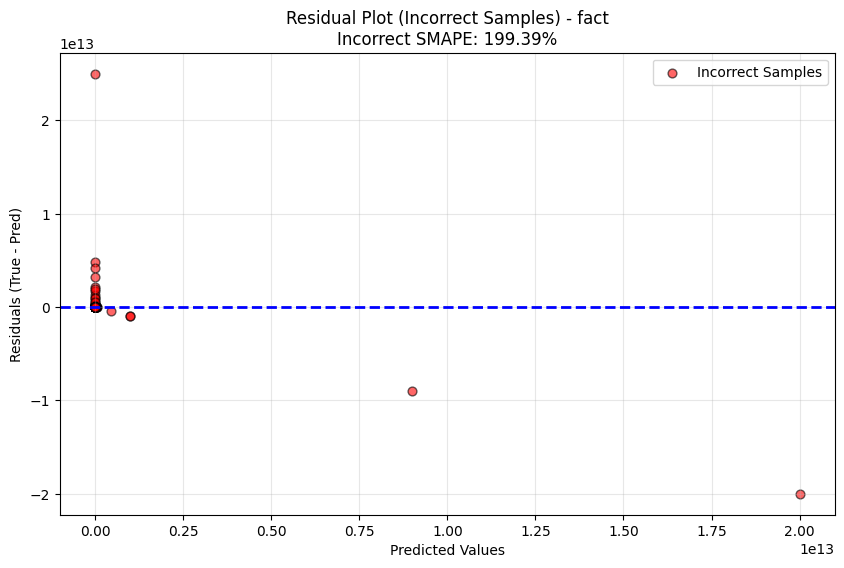

In [28]:
fact_metrics = evaluate_regression(test_ground_truths['fact'], test_predictions['fact'], 'fact')


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_smape_most_diff(y_true, y_pred, top_k=20):
    """
    Identifies and analyzes the samples with the highest SMAPE scores.
    Max SMAPE is 200%.
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)
    
    # 1. Calculate Element-wise SMAPE
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    
    # Handle 0/0 edge case
    with np.errstate(divide='ignore', invalid='ignore'):
        smape_values = (numerator / denominator) * 100
        smape_values[denominator == 0] = 0.0  # 0 vs 0 is 0% error
    
    # 2. Create Analysis DataFrame
    df = pd.DataFrame({
        'True': y_true,
        'Pred': y_pred,
        'Diff': y_true - y_pred,
        'SMAPE': smape_values
    })
    
    # Add diagnostic columns
    # Scale Diff: How many powers of 10 are we off? (log10 diff)
    # We add epsilon to avoid log(0)
    df['Log10_Diff'] = np.log10(np.abs(df['Pred']) + 1e-9) - np.log10(np.abs(df['True']) + 1e-9)
    
    # Sort by worst SMAPE
    df_sorted = df.sort_values(by='SMAPE', ascending=False)
    
    # 3. Print Analysis
    print(f"\n{'='*10} WORST SMAPE ANALYSIS (Top {top_k}) {'='*10}")
    print(f"Global Mean SMAPE: {df['SMAPE'].mean():.2f}%")
    print(f"Max Possible SMAPE is 200%.\n")
    
    top_offenders = df_sorted.head(top_k)
    
    # Formatting for cleaner output
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    print("--- Top Worst Samples ---")
    print(top_offenders[['True', 'Pred', 'SMAPE', 'Log10_Diff']].to_string(index=True))
    
    # 4. Automatic Diagnosis of the Top K
    print(f"\n--- Diagnosis of Top {top_k} Errors ---")
    
    zeros_issue = top_offenders[(top_offenders['True'] == 0) | (top_offenders['Pred'] == 0)]
    sign_issue = top_offenders[((top_offenders['True'] > 0) & (top_offenders['Pred'] < 0)) | 
                               ((top_offenders['True'] < 0) & (top_offenders['Pred'] > 0))]
    scale_issue = top_offenders[np.abs(top_offenders['Log10_Diff']) >= 1] # Off by at least 10x
    
    print(f"1. Zero-Value Conflicts (One is 0, other is not): {len(zeros_issue)}")
    print(f"2. Sign Mismatches (Positive vs Negative):        {len(sign_issue)}")
    print(f"3. Scale Failures (Off by >10x magnitude):        {len(scale_issue)}")

    # 5. Visualization
    plt.figure(figsize=(14, 6))
    
    # Plot A: SMAPE Distribution
    plt.subplot(1, 2, 1)
    sns.histplot(df['SMAPE'], bins=50, kde=True, color='teal')
    plt.axvline(x=df['SMAPE'].mean(), color='r', linestyle='--', label=f'Mean: {df["SMAPE"].mean():.1f}%')
    plt.title("Distribution of SMAPE Errors")
    plt.xlabel("SMAPE (%)")
    plt.legend()
    
    # Plot B: True vs Pred (Log Scale) highlighting Worst Offenders
    plt.subplot(1, 2, 2)
    
    # Plot all points in grey
    plt.scatter(np.abs(df['True']), np.abs(df['Pred']), alpha=0.1, color='gray', label='All Points')
    
    # Plot Top K in Red
    plt.scatter(np.abs(top_offenders['True']), np.abs(top_offenders['Pred']), 
                color='red', edgecolor='k', s=50, label=f'Top {top_k} Worst SMAPE')
    
    plt.xscale('log')
    plt.yscale('log')
    
    # Diagonal line
    min_val = min(np.abs(df['True']).min(), np.abs(df['Pred']).min()) + 1e-9
    max_val = max(np.abs(df['True']).max(), np.abs(df['Pred']).max())
    plt.plot([min_val, max_val], [min_val, max_val], 'b--', label='Perfect Pred')
    
    plt.xlabel("|True Value| (Log Scale)")
    plt.ylabel("|Predicted Value| (Log Scale)")
    plt.title(f"True vs Pred (Top {top_k} Highlighted)")
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    plt.tight_layout()
    plt.show()

# Usage Example:
# analyze_smape_most_diff(test_ground_truths['fact'], test_predictions['fact'], top_k=10)


========== WORST SMAPE ANALYSIS (Top 20) ==========
Global Mean SMAPE: 6.92%
Max Possible SMAPE is 200%.

--- Top Worst Samples ---
               True          Pred  SMAPE    Log10_Diff
11799 -2.600000e+06  2.600000e+06  200.0  0.000000e+00
55794 -5.293000e+06  5.293000e+06  200.0  0.000000e+00
78426 -2.000000e+05  2.000000e+05  200.0  6.471493e-09
55815 -1.400000e+06  1.400000e+06  200.0  0.000000e+00
11858 -4.430000e+07  4.430000e+07  200.0  0.000000e+00
78392 -6.800000e+07  6.800000e+07  200.0  0.000000e+00
36134 -8.000000e+05  8.000000e+05  200.0  0.000000e+00
55879 -9.000000e+05  9.000000e+05  200.0  0.000000e+00
78292 -3.200000e+06  3.200000e+06  200.0  6.471492e-09
12017  9.000000e+05 -9.000000e+05  200.0  0.000000e+00
36043 -5.080000e+07  5.080000e+07  200.0  0.000000e+00
78250 -8.900000e+07  8.900000e+07  200.0  0.000000e+00
12062 -1.280000e+07  1.280000e+07  200.0  0.000000e+00
35990 -3.100000e+06  3.100000e+06  200.0  0.000000e+00
73554 -1.500000e+07  1.500000e+07  200.0  

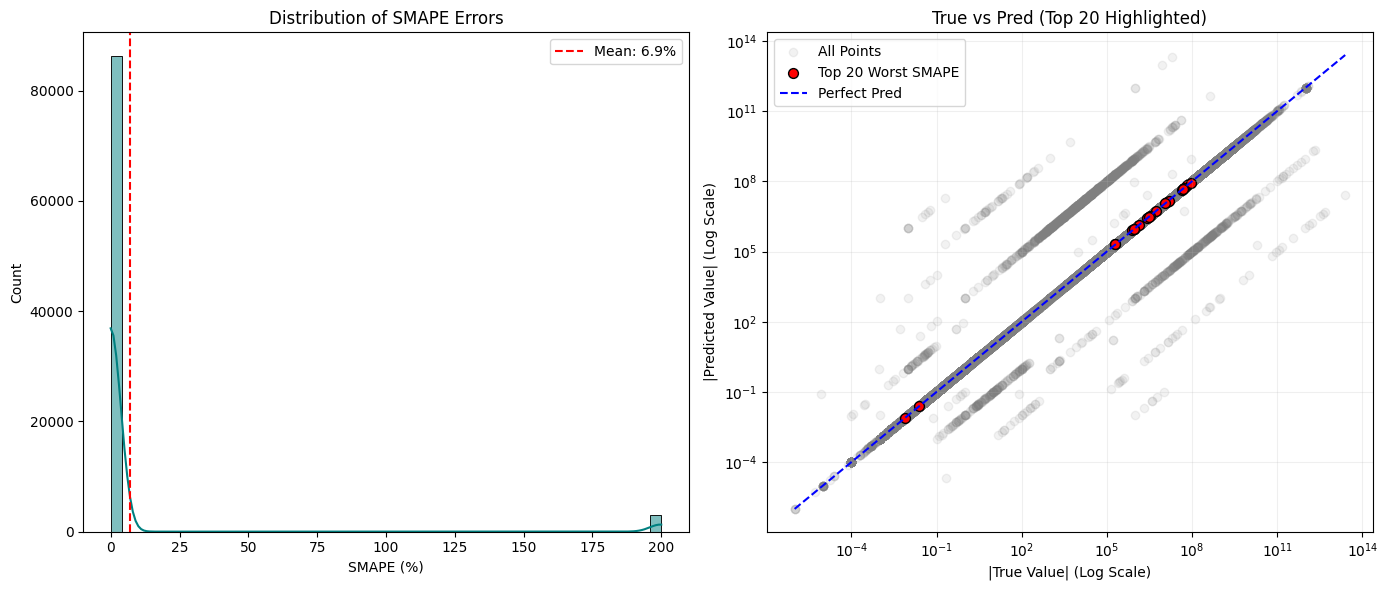

In [30]:
fact_metrics = analyze_smape_most_diff(test_ground_truths['fact'], test_predictions['fact'], top_k=20)

#### scale & fact evaluation

In [31]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_scale(scale_true, scale_preds):
    scale_acc = accuracy_score(scale_true, scale_preds)
    scale_f1 = f1_score(scale_true, scale_preds, average='macro')
    
    print(f"Scale Accuracy: {scale_acc:.4f}")
    print(f"Scale F1-score: {scale_f1:.4f}")
    
    return scale_acc, scale_f1


In [32]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_fact(fact_true, fact_preds, scale_true, scale_preds):
    # 轉換為 NumPy 陣列
    fact_true = np.asarray(fact_true)
    fact_preds = np.asarray(fact_preds)
    scale_true = np.asarray(scale_true)
    scale_preds = np.asarray(scale_preds)

    # 確保 fact 和 scale 的長度一致
    valid_mask = (scale_true != -100)  # 過濾無效 scale

    fact_true = fact_true[valid_mask]
    fact_preds = fact_preds[valid_mask]
    scale_true = scale_true[valid_mask]
    scale_preds = scale_preds[valid_mask]

    # 確保篩選後的長度相同
    if len(fact_true) != len(scale_true):
        print(f"Error: Mismatch in lengths after filtering! fact_true={len(fact_true)}, scale_true={len(scale_true)}")
        return None

    # 計算 scale 預測是否正確
    correct_scale_mask = (scale_preds == scale_true)  # Scale 預測正確的 mask
    incorrect_scale_mask = ~correct_scale_mask  # Scale 預測錯誤的 mask

    # 計算 RMSE、MAE、R²
    rmse = mean_squared_error(fact_true, fact_preds, squared=False)  # Root MSE
    mae = mean_absolute_error(fact_true, fact_preds)
    r2 = r2_score(fact_true, fact_preds)

    # 當 scale 預測正確時
    if correct_scale_mask.sum() > 0:
        rmse_correct = mean_squared_error(fact_true[correct_scale_mask], fact_preds[correct_scale_mask], squared=False)
        print(f"Fact RMSE (scale correct)  : {rmse_correct:.4f}")
    else:
        rmse_correct = None

    # 當 scale 預測錯誤時
    if incorrect_scale_mask.sum() > 0:
        rmse_incorrect = mean_squared_error(fact_true[incorrect_scale_mask], fact_preds[incorrect_scale_mask], squared=False)
        print(f"Fact RMSE (scale incorrect): {rmse_incorrect:.4f}")
    else:
        rmse_incorrect = None

    print(f"Fact RMSE: {rmse:.4f}")
    print(f"Fact MAE: {mae:.4f}")
    print(f"Fact R²: {r2:.4f}")

    return rmse, mae, r2, rmse_correct, rmse_incorrect


In [33]:
# 先評估 scale 預測
scale_acc, scale_f1 = evaluate_scale(test_ground_truths['scale'], test_predictions['scale'])

# 再評估 fact 預測
evaluate_fact(test_ground_truths['fact'], test_predictions['fact'], test_ground_truths['scale'], test_predictions['scale'])

Scale Accuracy: 0.9000
Scale F1-score: 0.3496


IndexError: boolean index did not match indexed array along dimension 0; dimension is 89386 but corresponding boolean dimension is 90337

In [ ]:
for key ,value in test_ground_truths.items():
    print (key,len(value))